In [ ]:


import matplotlib.pyplot as plt
from datasets import load_dataset
from collections import Counter

In [ ]:

dataset = load_dataset("beans")


print(dataset)


DatasetDict({
    train: Dataset({
        features: ['image_file_path', 'image', 'labels'],
        num_rows: 1034
    })
    validation: Dataset({
        features: ['image_file_path', 'image', 'labels'],
        num_rows: 133
    })
    test: Dataset({
        features: ['image_file_path', 'image', 'labels'],
        num_rows: 128
    })
})


Размеры выборок

In [ ]:

train = dataset["train"]
val = dataset["validation"]
test = dataset["test"]

print(f"Train: {len(train)} изображений")
print(f"Validation: {len(val)} изображений")
print(f"Test: {len(test)} изображений")
print(f"Всего: {len(train) + len(val) + len(test)} изображений")

Train: 1034 изображений
Validation: 133 изображений
Test: 128 изображений
Всего: 1295 изображений


Названия классов

In [ ]:
eng_names = train.features["labels"].names
print("Исходные классы:", eng_names)


ru_dict = {
    "angular_leaf_spot": "Угловатая пятнистость",
    "bean_rust": "Ржавчина фасоли",
    "healthy": "Здоровые"
}


class_names = [ru_dict[name] for name in eng_names]
num_classes = len(class_names)
print("Русские названия:", class_names)

Исходные классы: ['angular_leaf_spot', 'bean_rust', 'healthy']
Русские названия: ['Угловатая пятнистость', 'Ржавчина фасоли', 'Здоровые']


Распределение классов в обучающей выборке

Угловатая пятнистость: 345
Ржавчина фасоли: 348
Здоровые: 341


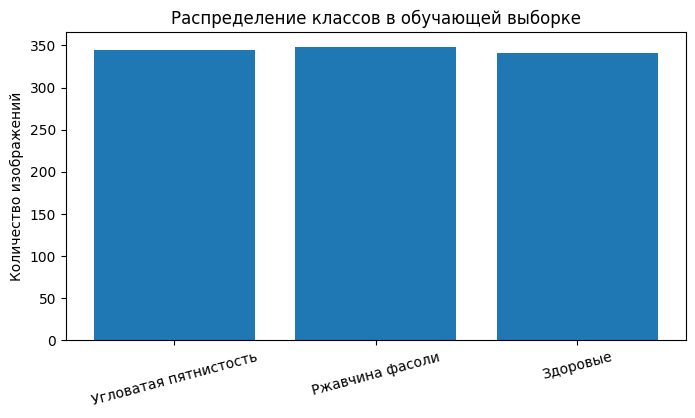

In [ ]:


train_labels = train["labels"]
label_counts = Counter(train_labels)

for i in range(num_classes):
    print(f"{class_names[i]}: {label_counts[i]}")


plt.figure(figsize=(8, 4))
plt.bar(class_names, [label_counts[i] for i in range(num_classes)])
plt.title("Распределение классов в обучающей выборке")
plt.ylabel("Количество изображений")
plt.xticks(rotation=15)
plt.show()

Распределение классов в валидационной и тестовой выборках

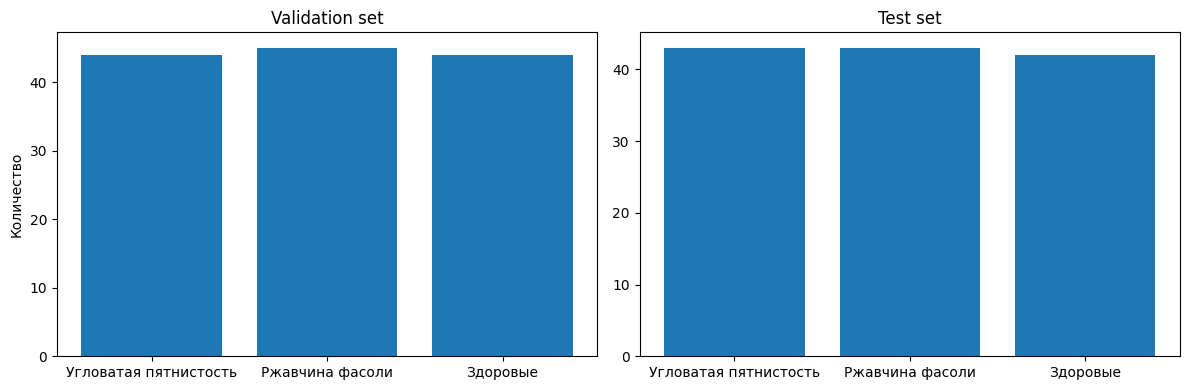

In [ ]:
val_labels = val["labels"]
test_labels = test["labels"]

fig, axes = plt.subplots(1, 2, figsize=(12,4))
axes[0].bar(class_names, [val_labels.count(i) for i in range(num_classes)])
axes[0].set_title("Validation set")
axes[0].set_ylabel("Количество")


axes[1].bar(class_names, [test_labels.count(i) for i in range(num_classes)])
axes[1].set_title("Test set")
plt.tight_layout()
plt.show()

Размеры изображений во всех выборках

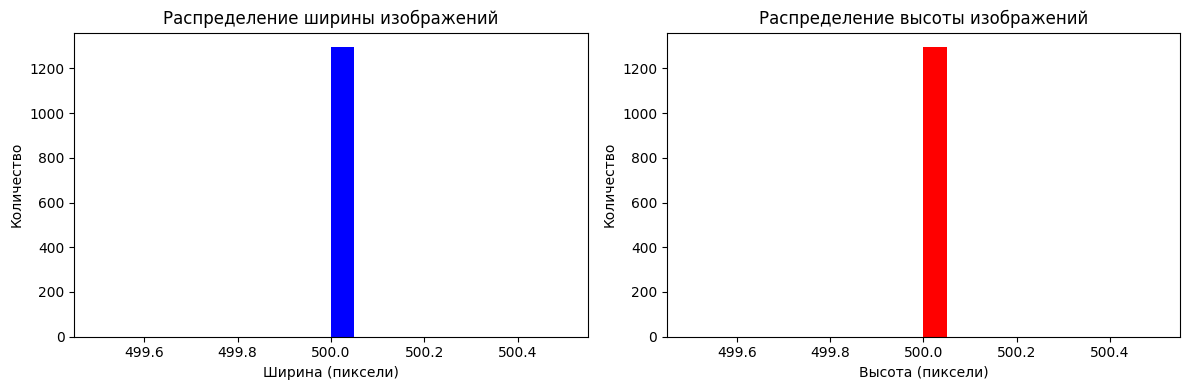

Размеры варьируются от 500x500 до 500x500


In [ ]:
all_images = list(train["image"]) + list(val["image"]) + list(test["image"])
widths, heights = [], []
for img in all_images:
    w, h = img.size
    widths.append(w)
    heights.append(h)

plt.figure(figsize=(12,4))
plt.subplot(1,2,1)
plt.hist(widths, bins=20, color='blue')
plt.title("Распределение ширины изображений")
plt.xlabel("Ширина (пиксели)")
plt.ylabel("Количество")

plt.subplot(1,2,2)
plt.hist(heights, bins=20, color='red')
plt.title("Распределение высоты изображений")
plt.xlabel("Высота (пиксели)")
plt.ylabel("Количество")
plt.tight_layout()
plt.show()
print(f"Размеры варьируются от {min(widths)}x{min(heights)} до {max(widths)}x{max(heights)}")

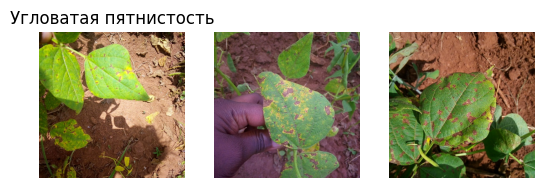

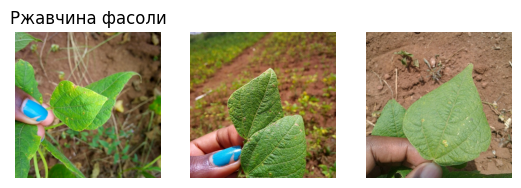

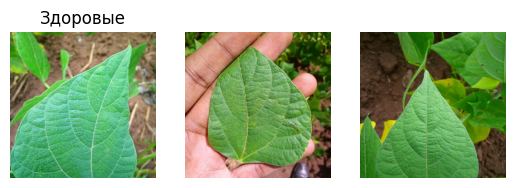

In [ ]:



for class_id, name in enumerate(class_names):
    indices = [i for i, lbl in enumerate(train["labels"]) if lbl == class_id][:3]

    for j, idx in enumerate(indices):
        plt.subplot(1, 3, j + 1)
        plt.imshow(train["image"][idx])
        plt.axis("off")
        if j == 0:
            plt.title(name)
    plt.show()

Проверка на поврежденные файлы

In [ ]:

import PIL.Image
corrupted = 0
for img in all_images:
    try:
        img.verify()
    except:
        corrupted += 1
print(f"Повреждённых изображений: {corrupted}")


Повреждённых изображений: 0
